## Continuación Regresión Lineal (desafio)

### Regresión lineal múltiple, para predecir el precio de una casa.

En este caso, trabajaremos con un set de datos de precios de casas del condado de King, Georgia, USA. El set de datos contiene 21 variables, pero no todas van a servir para el proceso de la regresión. Su tarea va a ser seleccionar las variables que va a descartar, y trabajar con el resto de las variables restantes para generar una regresión lineal múltiple utilizando Numpy para obtener los $\hat{\beta}$. Además de esto, calcule el $R^2$ y obtenga las métricas de error $MSE$, $MAE$ y $MAPE$.

**Desafío:** Puede que el uso de todas las variables no genere el mejor modelo. Por lo mismo, el **desafío** consiste en implementar el algoritmo de __Step Forward Feature Selection__. La idea de este algoritmo es agregar de a 1 en 1 las variables existentes en nuestro set de datos y ver como mejora el proceso de ajuste de la regresión lineal.

1. De las posibles variables consideradas en un principio (la cual llamaremos $m$), entrene $m$ modelos de regresión lineal (uno por cada variable), y seleccione la variable que obtenga un mejor $MAE$.

2. Con la variable seleccionada, remuévala del conjunto de posibles variables y guárdela en una lista de variables seleccionadas (`selected_vars`)

3. Del conjunto de posibles variables restantes, entrene $m-len(selected\_vars)$ modelos de regresión lineal utilizando las variables restantes en conjunto con `selected_vars`. Seleccione la nueva variable que obtenga un mejor $MAE$. Repita el paso 2. hasta que no quede ninguna variable.

4. Finalmente, con el procedimiento realizado, y ninguna variable restante en el conjunto de posible variable, imprima por pantalla el mejor conjunto de variables junto con su $MAE$. Adicionalmente, puede graficar la curva de cómo va evolucionando el $MAE$ a medida que va agregando variables.

**Nota:** Para el desafío, es recomendable utilizar `LinearRegression` de `scikit-learn` por temas de facilidad de implementación del algoritmo de __Step Forward Feature Selection__. Para poder obtener el $\hat{Y}$ utilizando `LinearRegression`, se debe utilizar el método `.predict(X)` posteriormente a haber ajustado el modelo (`.fit(X,y)`), y este computara:

$$\hat{Y}=\hat{\beta_0}+X_1\hat{\beta_1}+X_2\hat{\beta_2}+\dots+X_m\hat{\beta_m}$$

Ejemplo de uso:

```python
lr = LinearRegression()
lr.fit(X,y)
y_hat = lr.predict(X)
```

In [1]:
import pandas as pd
import numpy as np

housing_df = pd.read_csv("kc_house_data.csv")
housing_df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180.0,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170.0,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770.0,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050.0,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680.0,0,1987,0,98074,47.6168,-122.045,1800,7503


In [2]:
housing_df.keys()

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [3]:
# Su codigo aca ...
len(housing_df)

21613

In [4]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21611 non-null  float64
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [9]:
variables = ['bedrooms', 'bathrooms', 'sqft_living', \
           'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', \
           'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', \
           'sqft_living15', 'sqft_lot15']

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
lr = LinearRegression() # Y generamos un obtejo de LinearRegressión

housing_df = housing_df.fillna(0)
r2 = {}
y = housing_df['price']
for i in variables:
    X = housing_df[[i]]
    lr.fit(X, y)
    y_pred = lr.predict(X)
    r2[r2_score(y, y_pred)] = i
sorted_r2 = dict(sorted(r2.items(), reverse=True))
print(sorted_r2)

{0.4928532179037931: 'sqft_living', 0.44546848610928724: 'grade', 0.36652884686027465: 'sqft_above', 0.3426684607560172: 'sqft_living15', 0.27576939959239877: 'bathrooms', 0.15784211584121532: 'view', 0.104856815269744: 'sqft_basement', 0.09507947467657651: 'bedrooms', 0.07095267538578331: 'waterfront', 0.06594310068341092: 'floors', 0.015985504123854355: 'yr_renovated', 0.0080390699212195: 'sqft_lot', 0.006797532958571217: 'sqft_lot15', 0.002917245534412971: 'yr_built', 0.0013221797086615528: 'condition'}


In [19]:
max(r2)

0.4928532179037931

In [26]:
from itertools import combinations

pares = combinations(variables, 2)
p = list(pares)
print(len(variables), len(p), p)

15 105 [('bedrooms', 'bathrooms'), ('bedrooms', 'sqft_living'), ('bedrooms', 'sqft_lot'), ('bedrooms', 'floors'), ('bedrooms', 'waterfront'), ('bedrooms', 'view'), ('bedrooms', 'condition'), ('bedrooms', 'grade'), ('bedrooms', 'sqft_above'), ('bedrooms', 'sqft_basement'), ('bedrooms', 'yr_built'), ('bedrooms', 'yr_renovated'), ('bedrooms', 'sqft_living15'), ('bedrooms', 'sqft_lot15'), ('bathrooms', 'sqft_living'), ('bathrooms', 'sqft_lot'), ('bathrooms', 'floors'), ('bathrooms', 'waterfront'), ('bathrooms', 'view'), ('bathrooms', 'condition'), ('bathrooms', 'grade'), ('bathrooms', 'sqft_above'), ('bathrooms', 'sqft_basement'), ('bathrooms', 'yr_built'), ('bathrooms', 'yr_renovated'), ('bathrooms', 'sqft_living15'), ('bathrooms', 'sqft_lot15'), ('sqft_living', 'sqft_lot'), ('sqft_living', 'floors'), ('sqft_living', 'waterfront'), ('sqft_living', 'view'), ('sqft_living', 'condition'), ('sqft_living', 'grade'), ('sqft_living', 'sqft_above'), ('sqft_living', 'sqft_basement'), ('sqft_living

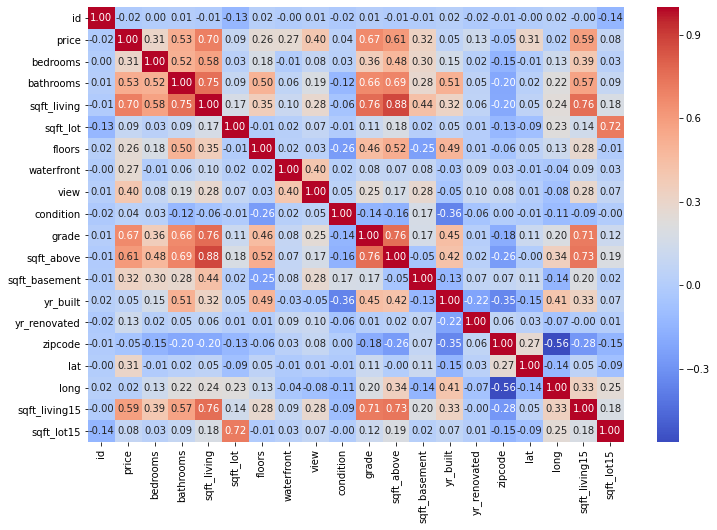

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = housing_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f')

plt.show()

In [55]:
lr = LinearRegression() # Y generamos un obtejo de LinearRegressión

housing_df = housing_df.fillna(0)
r2 = {}
y = housing_df['price']
maximo = 0
from itertools import combinations

for i in range(len(variables)):
    grupos = combinations(variables, i+1)
    g = list(grupos)

    for j in g:
        var = []
        for k in j:
            var.append(k)
        #print(var)
        X = housing_df[var]
        lr.fit(X, y)
        y_pred = lr.predict(X)
        r2t = r2_score(y, y_pred)
        r2[r2t] = j
        if r2t > maximo:
            maximo = r2t
    if maximo > 0.64:
        print(j)
        break
        
sorted_r2 = dict(sorted(r2.items(), reverse=True))
print(sorted_r2)

('sqft_basement', 'yr_built', 'yr_renovated', 'sqft_living15', 'sqft_lot15')
{0.6414883805154602: ('sqft_living', 'waterfront', 'view', 'grade', 'yr_built'), 0.6386061168772885: ('bedrooms', 'sqft_living', 'waterfront', 'grade', 'yr_built'), 0.6367436014229226: ('bathrooms', 'sqft_living', 'waterfront', 'grade', 'yr_built'), 0.6352279311451672: ('sqft_living', 'floors', 'waterfront', 'grade', 'yr_built'), 0.6351407030972014: ('sqft_living', 'waterfront', 'grade', 'yr_built', 'sqft_lot15'), 0.6344604559566256: ('sqft_living', 'sqft_lot', 'waterfront', 'grade', 'yr_built'), 0.634458046364422: ('sqft_living', 'waterfront', 'grade', 'yr_built', 'sqft_living15'), 0.6344406065088132: ('sqft_living', 'waterfront', 'condition', 'grade', 'yr_built'), 0.6341453960864748: ('sqft_living', 'waterfront', 'grade', 'yr_built', 'yr_renovated'), 0.6339752028983574: ('sqft_living', 'waterfront', 'grade', 'sqft_basement', 'yr_built'), 0.6339726954443174: ('waterfront', 'grade', 'sqft_above', 'sqft_basemen

In [56]:
print(maximo)

0.6414883805154602


In [51]:
for i in sorted_r2:
    print(sorted_r2[i])
    X = housing_df[list(sorted_r2[i])]
    lr.fit(X, y)
    y_pred = lr.predict(X)
    break

('sqft_living', 'grade', 'yr_built')


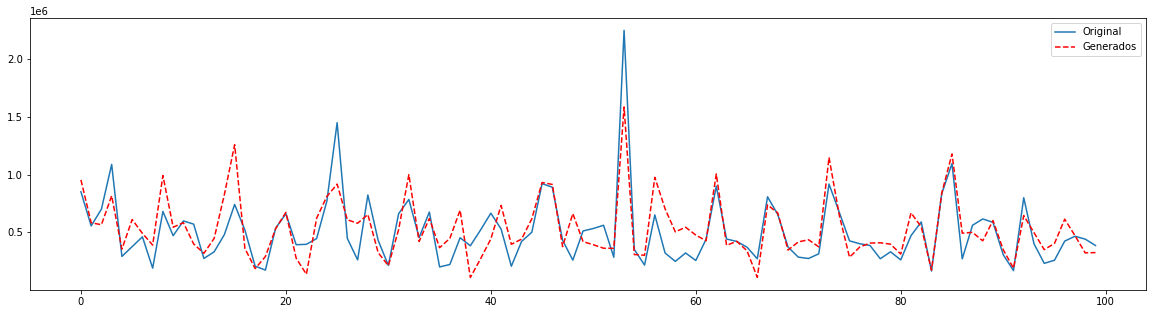

In [54]:
plt.figure(figsize=(20,5))
plt.plot(np.arange(100), y[100:200], label="Original")
plt.plot(np.arange(100), y_pred[100:200],'--', color="red", label="Generados")

plt.legend()

plt.show()